# Power analysis attack on AES with custom SBox 

## Configuration

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import serial.tools.list_ports as port_list
import sys

sys.path.append( '../../../ciphers/AES_python' )
sys.path.append( '../../../sca_scripts' )

# Set the S-Box to test
tested_sbox = "sbox_rijandael"
sbox_id = tested_sbox.replace("sbox_", "")

In [11]:
# If capure is set to True, the script will capture data from the PicoScope
capture = False
# If save_dataset is set to True, the script will save the captured data to a .dat file
save_dataset = True

In [12]:
sys.path.append('../../../sca_scripts/utils')
from dat_tracereader import dat_tracereader

# Configuration parameters
pt_len = 16  # size of the plaintext in bytes
ct_len = 16  # size of the ciphertext in bytes
key_len = 16  # size of the key in bytes
n_trc = 5000  # number of traces to capture or read from dataset
    
if not capture:
    try:
        reader = dat_tracereader()
        reader.open_ro("../../dataset/aes_"+sbox_id+".dat")
        trace, key, plaintext, ciphertext =  reader.read_traces(n_trc)
        num_samples = trace.shape[1]  # number of samples per trace
        reader.close()
    except Exception as e:
        print("Error loading dataset: ", e)
else: 
    # Allocate memory for traces and data
    num_samples = 1612
    trace = np.empty((n_trc, num_samples), dtype=np.float64)  
    plaintext = np.empty((n_trc, pt_len), dtype=np.uint8)  
    ciphertext = np.empty((n_trc, ct_len), dtype=np.uint8)  
    key = np.empty(key_len, dtype=np.uint8) 

## Optional online phase : AES power traces capture

### Picoscope and CW305 initialization and capture of power traces

In [ ]:
from tqdm.notebook import tnrange
import chipwhisperer as cw
from Crypto.Cipher import AES
from pico_api import PS5000aWrapper
from CW305_api import CW305Wrapper
from AES_golden import AES_golden_model
import time

if capture:
    # Set the bitstream file path based on the S-Box
    bitstream = r"../../../../hw/fpga/bitstream/aes/aes_single_round/cw305_top_"+sbox_id+"_lut.bit"

        # Load the bitstream on the CW305 board and initialize the PicoScope
    try:
        # Initialize picoscope
        ps = PS5000aWrapper()
        ps.get_unitInfo()
        ps.scope_setup()
        num_samples = ps.nSamples
        # Initialize CW305
        cw305 = CW305Wrapper(ps, bitstream)
    except ModuleNotFoundError as e:
        print(e)
    
    # Initialize key,text pair generator
    ktp = cw.ktp.Basic()
    key, plaintext[0] = ktp.next()

    # Initialize the AES software emulated cipher
    cipher = AES_golden_model()

    # Each element of the key is converted to a 2-digit hex string 
    formatted_key = ''.join(format(el, '02x') for el in key)
    print("Key: ", [ hex(subkey) for subkey in key])

    # Write the key to the CW305
    cw305.set_key(key)

    # Dummy capture call due to bug of using AC coupling
    cw305.capture_trace(plaintext[0])

    for i in tnrange(n_trc, desc='Capturing traces'):
        ciphertext[i], trace[i] = cw305.capture_trace(plaintext[i])
        # Sanity check with expected ciphertext
        formatted_pt = (format(el, '02x') for el in plaintext[i])
        text = [int(subbyte, 16) for subbyte in formatted_pt]
        assert (list(ciphertext[i]) == list(cipher.encrypt(formatted_key, text, tested_sbox))), "Incorrect encryption result!\nGot {}\nExp {}\n".format(list(ciphertext[i]), list(plaintext[i]))
        if (i < n_trc-1):
            _ , plaintext[i+1] = ktp.next() 

    # Disconnect CW305 and picoscope
    cw305.dis()
    ps.dis()

    # If save_dataset is set to True, the attack data are stored to a .dat file
    if (save_dataset):
        try:
            writer = dat_tracereader()
            key = np.array(key, dtype=np.uint8)
            writer.create(
                pathname="dataset/aes_"+sbox_id+".dat",
                trace_len=int(num_samples),
                sample_type='d',
                key_len=key_len,
                plaintext_len=pt_len,
                ciphertext_len=ct_len
            )
            writer.write_traces(trace, key, plaintext, ciphertext)
            print("Traces written:", writer.num_traces)
            writer.close()
        except Exception as e:
            print("Error saving dataset: ", e)

## Offline phase : attack on captured traces

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
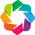

In [5]:
import os
import chipwhisperer.analyzer as cwa
import chipwhisperer as cw
import holoviews as hv
hv.extension('bokeh')
from analyzer.attack.aes.SBox_leakage_models import AES128SboxResistantLeakageModels
from analyzer.attack.aes.key_schedule import key_schedule_rounds
from analyzer.utils.sca_plots import sca_plot

### Plotting power traces captured (40 traces overlapped)

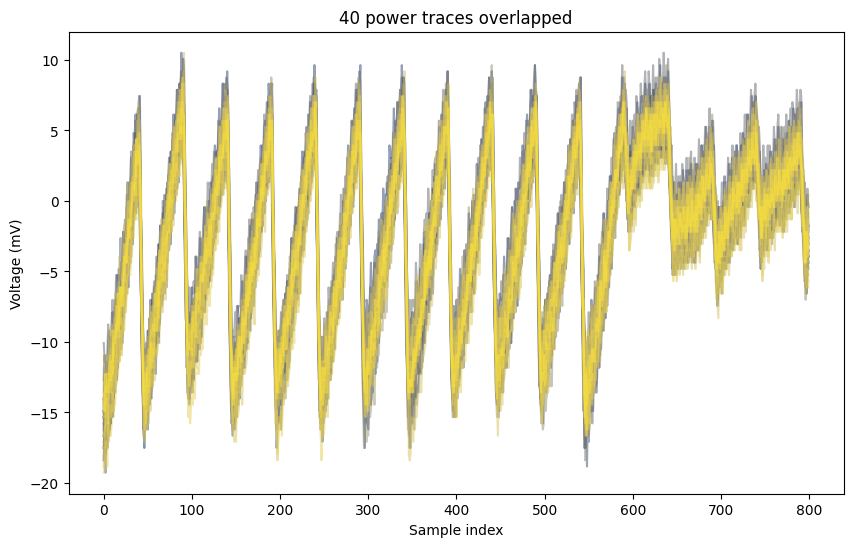

<Figure size 640x480 with 0 Axes>

In [ ]:
sca_plt = sca_plot()
power_plt = sca_plt.power_traces_overlapped(traces=list(trace), finish=800)
power_plt.show()
# Ensure the Graphs directory exists
os.makedirs("Graphs", exist_ok=True)
power_plt.savefig("Graphs/power_traces_overlapped"+tested_sbox+".png")

# Hamming distance attack : 
## state difference leakage model on last round due to missing mix column operation

## Attacking the Register Update Operation (Brief Description)

The targeted leakage point is the **register update** operation:

$$
\text{Register A}_{new} = \text{shiftLayer}(\text{sboxLayer}(S_{in})) \oplus key
$$

We exploit leakage by computing the **Hamming distance** between the updated register state (output of round 9) and the ciphertext (output of round 10):

$$
HD(\text{Register A}_{new}, \text{Ciphertext}) 
$$

This metric allows identifying the correct key byte through correlation with power trace since the hamming distance corresponds to number of bits that flipped between two consecutive states.

The subkey guess is affected by the shiftLayer  

$$
S_{in}[byte] = SBox^{-1}(Shift^{-1}(output[byte] \oplus key[byte])) = SBox^{-1}(Shift^{-1}(output[byte]) \oplus Shift^{-1}(key[byte])) =  SBox^{-1}(Shift^{-1}(output[byte]) \oplus keyGuess)
$$



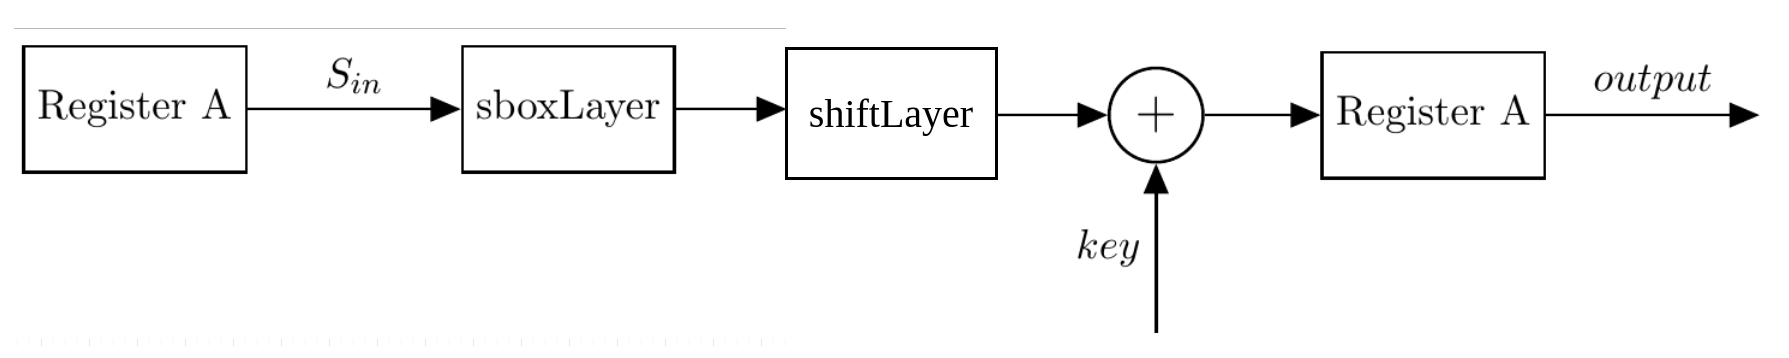

In [10]:
from analyzer.attack.aes.key_schedule import key_schedule_rounds
key_last_round = key_schedule_rounds(key, 0, 10, tested_sbox)
print("Exepcted last round key :\n", [hex(subkey) for subkey in key_last_round])

Exepcted last round key :
 ['0xd0', '0x14', '0xf9', '0xa8', '0xc9', '0xee', '0x25', '0x89', '0xe1', '0x3f', '0xc', '0xc8', '0xb6', '0x63', '0xc', '0xa6']


In [ ]:
import sys
import numpy as np
from tqdm.notebook import tqdm
sys.path.append('../sca_scripts/analyzer/attack/aes')
from sbox_modified_funcs import inv_sbox_lut

n_candidates = 256

# Create list of hamming weight
hw = [bin(i).count("1") for i in range(n_candidates)]

def hamming_distance(a,b):
    return hw[(a^b)]

SHIFT_undo = [0, 13, 10, 7, 4, 1, 14, 11, 8, 5, 2, 15, 12, 9, 6, 3]

def compute_hd_round9_vs_round10(
    ct: np.ndarray,  # Ciphertexts of shape (num_traces, 16)
    bnum: int,  # The byte number to attack (0-15)
    verbose: bool = False  # Whether to show progress
    ) -> np.ndarray:
    """
    Compute the Hamming distance between output of round 9 and round 10 (byte-wise)
    for all key byte guesses (0-255), across multiple power traces.

    Parameters
    ----------
    ct : np.ndarray
        2-D array of shape (num_traces, 16) containing the captured ciphertexts
        (16-byte ciphertexts for each trace).

    bnum : int
        The byte number to attack (0-15).

    verbose : bool, default False
        If True, show a progress bar via tqdm. Set to False for batch scripts.

    Returns
    -------
    np.ndarray
        Array of shape (num_traces, 256) containing the Hamming distances.
        y_hd[i, k] is the HD between the attacked byte in trace i and the predicted
        round-9 output with key guess k.
    """
    # ----------------------------------------------------------- #
    # Input sanity checks                                        #
    # ----------------------------------------------------------- #
    if ct.dtype != np.uint8:
        raise TypeError("ct must have dtype uint8.")
    
    # Parameters
    n_candidates = 256
    n_traces = ct.shape[0]
    
    # Initialize the result array for Hamming distances
    y_hd = np.empty((n_traces, n_candidates), dtype=np.uint8)

    # Loop over each trace and key guess
    loop_range = tqdm(range(n_traces), desc='Computing hamming distances') if verbose else range(n_traces)
    
    for i in loop_range:
        # Round 10 output
        st10 = ct[i, bnum]  # No need to modify for round 10 since it's the same byte
        for k_guess in range(n_candidates):
            # Compute round 9 output based on the guessed key
            st9 = np.uint8(inv_sbox_lut(ct[i, SHIFT_undo[bnum]] ^ k_guess, tested_sbox))
            
            # Compute Hamming distance between round 9 output and the target round 10 byte
            y_hd[i, k_guess] = hamming_distance(st10, st9)

    return y_hd


def compute_correlation_trace_vs_hd(traces: np.ndarray,
                                    y_hd: np.ndarray,
                                    verbose: bool = False):
    """
    Correlate a leakage model (Hamming-distance matrix) with power-trace samples.

    Parameters
    ----------
    traces : np.ndarray
        Shape (n_traces, n_samples). Each row is one power-trace; each column a time sample.
    y_hd   : np.ndarray
        Shape (n_traces, 256). Hamming-distance values for every key guess (0-255)
        and every trace. *Must be computed beforehand*.

    Returns
    -------
    r_max   : np.ndarray
        Shape (256,). Maximum absolute correlation per key guess (the usual “CPA score”).
    """
    n_candidates = 256
    n_traces, num_samples = traces.shape
    r = np.empty((n_candidates, num_samples), dtype=np.float64)
    
    loop_range = tqdm(range(n_candidates), desc='Computing correlation') if verbose else range(n_candidates)

    for k_guess in loop_range:
        for smp in range(num_samples):
            r[k_guess, smp] = np.corrcoef(traces[:, smp], y_hd[:, k_guess])[0, 1]

    # --- Key-ranking metric: max |r| for each key guess -------------------------
    r_max = np.max(np.abs(r), axis=1)      
                        
    return r_max

## Key retrieval

In [12]:
p = np.empty((256, key_len), dtype=np.uint8)   # rankings
R = np.empty_like(p, dtype=np.float64)         # correlations

for k_byte in tqdm(range(key_len), desc='Recovering key bytes'):
    # Compute the Hamming distance vs. round-9 output for the attacked byte
    hamming_dists  = compute_hd_round9_vs_round10(ciphertext, k_byte) 
    # Compute the correlation between the power traces and the Hamming distance
    r_max = compute_correlation_trace_vs_hd(trace, hamming_dists)
    
    order = np.argsort(r_max)[::-1]                  # key guess : best → worst
    p[:, SHIFT_undo[k_byte]] = order                 # store  key ranking
    R[:, SHIFT_undo[k_byte]] = r_max[order]          # store corr. in ranking order

Recovering key bytes:   0%|          | 0/16 [00:00<?, ?it/s]

In [13]:
import pandas as pd
top_n = 10                           # Keep only the first 10 candidates

# Slice the first 25 rows (rank-0 … rank-24)
p_top = p[:top_n, :]
R_top = R[:top_n, :]

# ──────────────────────────────────────────────────────────────────────────────
# 2. Create a DataFrame 
# ──────────────────────────────────────────────────────────────────────────────
# Each cell: "0x<hex>\n<corr>"
fmt_cell = np.vectorize(lambda g, c: f"0x{g:02X}\n{c:+.4f}")
df = pd.DataFrame(
    fmt_cell(p_top, R_top),
    index=[f"#{rank}" for rank in range(top_n)],
    columns=[f"byte {i}" for i in range(key_len)]
)

# ──────────────────────────────────────────────────────────────────────────────
# 3. Styling helper – paint the correct guess in red
# ──────────────────────────────────────────────────────────────────────────────
def highlight_correct(col, correct):
    """Return styling list for a DataFrame column."""
    styles = []
    for cell in col:
        guess_hex = cell.split('\n')[0]          # "0x2A"
        guess = int(guess_hex, 16)
        styles.append("background-color:lightcoral" if guess == correct else "")
    return styles

styler = df.style
for j in range(key_len):
    styler = styler.apply(highlight_correct, correct=key_last_round[j], subset=[f"byte {j}"])

# Optional aesthetics
styler = (styler
          .set_properties(**{"white-space": "pre"})     # keep the line break
          .set_caption("CPA ranking – guess / correlation"))
# Display the styled DataFrame

styler

,byte 0,byte 1,byte 2,byte 3,byte 4,byte 5,byte 6,byte 7,byte 8,byte 9,byte 10,byte 11,byte 12,byte 13,byte 14,byte 15
#0,0xD0 +0.1083,0x14 +0.1176,0xF9 +0.0991,0xA8 +0.1003,0xC9 +0.1035,0xEE +0.1026,0x25 +0.1091,0x89 +0.0979,0xE1 +0.1094,0x3F +0.1049,0x0C +0.0731,0xC8 +0.0779,0xB6 +0.0649,0x63 +0.1220,0x0C +0.0973,0xA6 +0.0938
#1,0x1B +0.0525,0x6E +0.0655,0x94 +0.0683,0xCF +0.0575,0xC3 +0.0558,0x5B +0.0642,0x1D +0.0658,0x0A +0.0591,0x1B +0.0589,0xE2 +0.0587,0x2B +0.0576,0xA2 +0.0711,0x16 +0.0541,0xA1 +0.0594,0x56 +0.0605,0xE7 +0.0588
#2,0xFA +0.0524,0x7B +0.0572,0x8E +0.0531,0xBD +0.0538,0xCD +0.0540,0x83 +0.0517,0x0A +0.0584,0x8A +0.0544,0xD4 +0.0551,0xA9 +0.0584,0x67 +0.0549,0x24 +0.0585,0x48 +0.0538,0x62 +0.0588,0xCB +0.0590,0x58 +0.0534
#3,0x53 +0.0520,0x1A +0.0564,0x88 +0.0522,0xEA +0.0532,0xFA +0.0535,0x1A +0.0509,0x60 +0.0577,0x15 +0.0480,0x4E +0.0523,0x47 +0.0517,0x85 +0.0547,0xF8 +0.0558,0xD5 +0.0518,0xB0 +0.0586,0x41 +0.0551,0x3D +0.0494
#4,0x6D +0.0515,0x88 +0.0555,0xB5 +0.0520,0x11 +0.0522,0xBA +0.0521,0x17 +0.0508,0x93 +0.0525,0x41 +0.0480,0x26 +0.0512,0xD2 +0.0514,0xE5 +0.0530,0x8D +0.0543,0x5B +0.0506,0x07 +0.0552,0xC6 +0.0550,0xF6 +0.0488
#5,0x6A +0.0514,0xF3 +0.0519,0x1D +0.0514,0xF8 +0.0501,0x87 +0.0517,0x79 +0.0500,0x3E +0.0509,0x13 +0.0472,0xB1 +0.0509,0xD1 +0.0511,0x73 +0.0510,0xF2 +0.0533,0xFF +0.0492,0x35 +0.0535,0x31 +0.0528,0x94 +0.0485
#6,0xA1 +0.0501,0x99 +0.0495,0x62 +0.0509,0xFC +0.0498,0x80 +0.0503,0x66 +0.0486,0xA9 +0.0509,0xCA +0.0465,0x09 +0.0508,0x42 +0.0497,0x4C +0.0500,0x3B +0.0525,0x7C +0.0486,0xB1 +0.0524,0xF7 +0.0506,0x5A +0.0479
#7,0x2B +0.0490,0x9E +0.0493,0x30 +0.0497,0x1C +0.0496,0xC0 +0.0494,0xB5 +0.0485,0xE6 +0.0483,0xCD +0.0452,0x02 +0.0503,0x0A +0.0488,0x01 +0.0494,0xD0 +0.0523,0xDB +0.0477,0xE4 +0.0519,0x35 +0.0500,0x8A +0.0474
#8,0x59 +0.0482,0xD5 +0.0492,0xCD +0.0494,0x3F +0.0493,0x5D +0.0486,0xDB +0.0475,0x8B +0.0478,0x0F +0.0452,0x2A +0.0493,0xE4 +0.0486,0x3E +0.0494,0x27 +0.0520,0x8D +0.0473,0xB8 +0.0510,0x60 +0.0488,0x89 +0.0472
#9,0x0B +0.0481,0x5E +0.0484,0xAF +0.0494,0x40 +0.0493,0xDD +0.0475,0x05 +0.0463,0xD1 +0.0461,0x9C +0.0451,0x47 +0.0492,0xFE +0.0485,0xB8 +0.0492,0xFB +0.0510,0x90 +0.0471,0xA6 +0.0505,0x1F +0.0485,0xF5 +0.0470


# TODO : Finish CPA multithread implementation and finish the correlation graph

In [ ]:
plt.figure()
plt.title('Correlation of correct sub-keys vs wrong guessed sub-keys')
plt.xlabel('key guess')
plt.ylabel('Correlation')
for subkey in range(key_len):
    plt.plot(R[:, subkey], label=f'Key byte {subkey}')
    for i in range(n_candidates):
            if i== key_last_round[subkey]:
                    plt.plot(R[i],'r',label=i)
            else:
                    plt.plot(R[i],'tab:gray', alpha=0.1)
    plt.legend()
    plt.show()

## Multi-thread CPA attack

In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from typing import Optional

# ──────────────────────────────────────────────────────────────────────────
# Helper executed in each worker process
# ──────────────────────────────────────────────────────────────────────────
def _recover_one_byte(args):
    """
    Worker function: recover a single key byte and return its ranking
    and correlation vector sorted from best to worst.

    Parameters
    ----------
    args : tuple
        (k_byte, ciphertext, trace) – packed so the executor can map().
        `ciphertext`  : np.ndarray shape (n_traces, 16)
        `trace`       : np.ndarray shape (n_traces, n_samples)

    Returns
    -------
    k_byte : int
        Index of the byte just processed (0…15).
    order  : np.ndarray shape (256,) dtype uint8
        Key-byte guesses sorted by descending correlation.
    r_rank : np.ndarray shape (256,) dtype float64
        Corresponding correlation values (already sorted like `order`).
    """
    k_byte, ciphertext, trace = args

    # 1) Extract the byte after InvShiftRows (row-major layout)
    st10 = ciphertext[:, SHIFT_undo[k_byte]]

    # 2) Build the HD model and correlate
    hamming_dists = compute_hd_round9_vs_round10(st10)
    r_max         = compute_correlation_trace_vs_hd(trace, hamming_dists)

    # 3) Sort best → worst
    order  = np.argsort(r_max)[::-1]           # uint8
    r_rank = r_max[order]                      # float64

    return k_byte, order.astype(np.uint8), r_rank


# ──────────────────────────────────────────────────────────────────────────
# Main routine – parallel recovery of all 16 bytes
# ──────────────────────────────────────────────────────────────────────────
def recover_key_bytes_parallel(ciphertext: np.ndarray,
                               trace: np.ndarray,
                               key_len: int = 16,
                                max_workers: Optional[int] = None):
    """
    Recover each key byte in parallel; returns (p, R) exactly like
    the sequential version.

    Parameters
    ----------
    ciphertext : np.ndarray
        Shape (n_traces, 16) uint8 – last-round ciphertexts.
    trace : np.ndarray
        Shape (n_traces, n_samples) float64 – power traces.
    key_len : int, default 16
        Number of key bytes (AES-128 → 16).
    max_workers : int | None
        Passed to ProcessPoolExecutor.  None → use os.cpu_count().

    Returns
    -------
    p : np.ndarray
        Shape (256, key_len) uint8 – rankings (best guess at row 0).
    R : np.ndarray
        Shape (256, key_len) float64 – correlations sorted the same way.
    """
    p = np.empty((256, key_len), dtype=np.uint8)
    R = np.empty_like(p, dtype=np.float64)

    with ProcessPoolExecutor(max_workers=max_workers) as ex:
        # Dispatch all jobs at once
        futures = [ex.submit(_recover_one_byte,
                             (k, ciphertext, trace))
                   for k in range(key_len)]

        # Progress bar over completed futures
        for fut in tqdm(as_completed(futures),
                        total=key_len,
                        desc="Recovering key bytes (parallel)"):
            k_byte, order, r_rank = fut.result()
            p[:, k_byte] = order
            R[:, k_byte] = r_rank

    return p, R

p, R = recover_key_bytes_parallel(ciphertext, trace)